<a href="https://colab.research.google.com/github/roohiverma-05/CMB-Analysis/blob/main/B_Mode_Polarizations_and_Secondary_Induced_Gravitational_Waves_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Studying B-Mode Polarizations: Secondary Induced Gravitational Waves from Primordial Blackholes in Gaussian Universe

This is my intituitive understanding of the matter. Though this subject involves study of advanced tensor calculus, pertubation theory and Quantum mechanics, I tried understanding the Phyics/intuition and the output formulas which I eventually coded.

In our case I have assumed a universe that follows gaussian nature that is our assumptions are:


1.   Universe on an average is uniform
2.   The existence of extremely hot or cold regions is rare.
3.   Everything is kind of symmetrical.

Though, this assumption leads to a problem that due to such a scenario our probabilities for the occurrence of High mass Primordial Black holes significantly decreases. Almost not possible/ highly improbable. So non gaussianties are important to to be considered.

On a classical or large scale the Gaussian nature of the Universe is preserved. The non-gaussianity parameter f_NL is zero at large scale structures like Galactic Clusters and etc.

But at microscopic scales due to pertubation effects and density fluctuations in the fabric of space-time the occurence of Primordial Black Holes is ensured.

## Production of a Primordial Black hole

You don't need a dying star but a scalar pertubation in the fabric of space-time. As this collapse due to the scalar pertubation occurs a black hole is formed. This highly energetic process sends ripples in space. As the ripples are sent out into space. The universe in its plasma state has a large pool of electrons. Scattering of CMB photons in a specific polarization occurs. This is the B-mode polarization.  

We will create a Primordial Power spectrum to represent the formation of PBH. Then we will make a Gravitational Power Sppectrum, and CMB B-Mode Power Spectrum.

## Primordial Power Spectrum

I'll code a spike in a graph to represent a pertubation spike to show creation of PBH. This is very simplified and unlike the actual stuff cosmologists do...

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1031/2956849250.py:32: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Scalar Power Spectrum $\mathcal{P}_\zeta(k)$", fontsize=12)


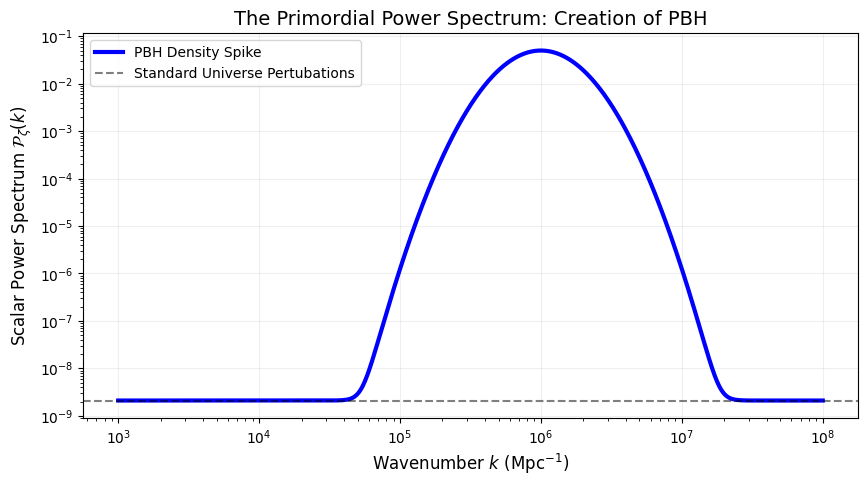

In [ ]:
# Defining k on the x-axis. We define log scale. k = wavenumber
k = np.logspace(3, 8, 1000)

def primordial_power_spectrum(k, A_spike, k_star, sigma):
  # Calculate the density fluctuations of the early universe:
  standard_ripple_amplitude = 2.1e-9 # Planck Data
  P_standard = standard_ripple_amplitude * np.ones_like(k)

  # Creating the spike:
    # Tallness of Spike (A_spike)
    # At what physical scale does it happen (k_star)
    # sigma: variance/ width of the spike
  exponent = - (np.log(k / k_star)**2) / (2 * sigma**2)
  P_spike = A_spike * np.exp(exponent)

  return P_standard + P_spike

amplitude = 0.05
scale = 1e6
width = 0.5

P_zeta = primordial_power_spectrum(k, amplitude, scale, width)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(k, P_zeta, color='blue', lw=3, label="PBH Density Spike")
plt.axhline(2.1e-9, color='black', linestyle='--', alpha=0.5, label="Standard Universe Pertubations")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Wavenumber $k$ (Mpc$^{-1}$)", fontsize=12)
plt.ylabel("Scalar Power Spectrum $\mathcal{P}_\zeta(k)$", fontsize=12)
plt.title("The Primordial Power Spectrum: Creation of PBH", fontsize=14)
plt.legend()

plt.grid(alpha=0.2)
plt.show()


## The Gravitational Wave Production

In actual the math is very intense. A brief Physics intuition is given here.

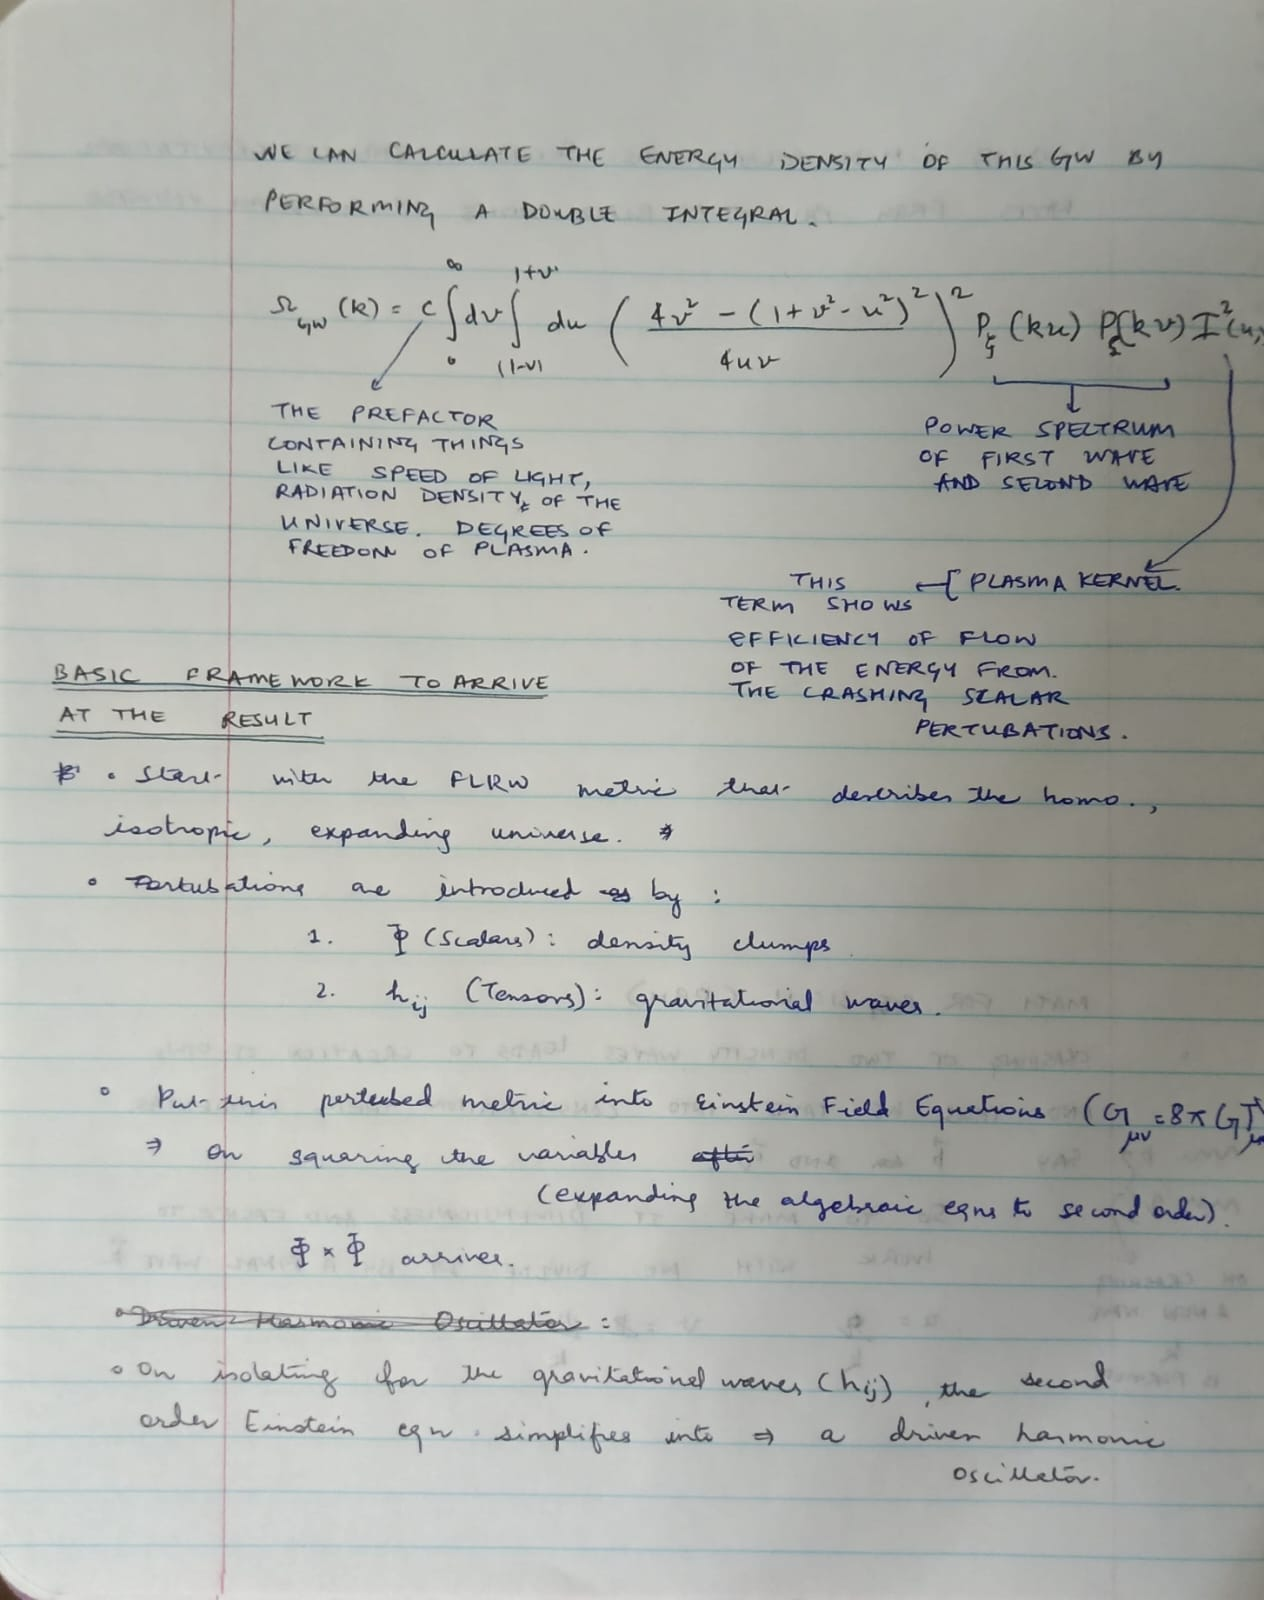

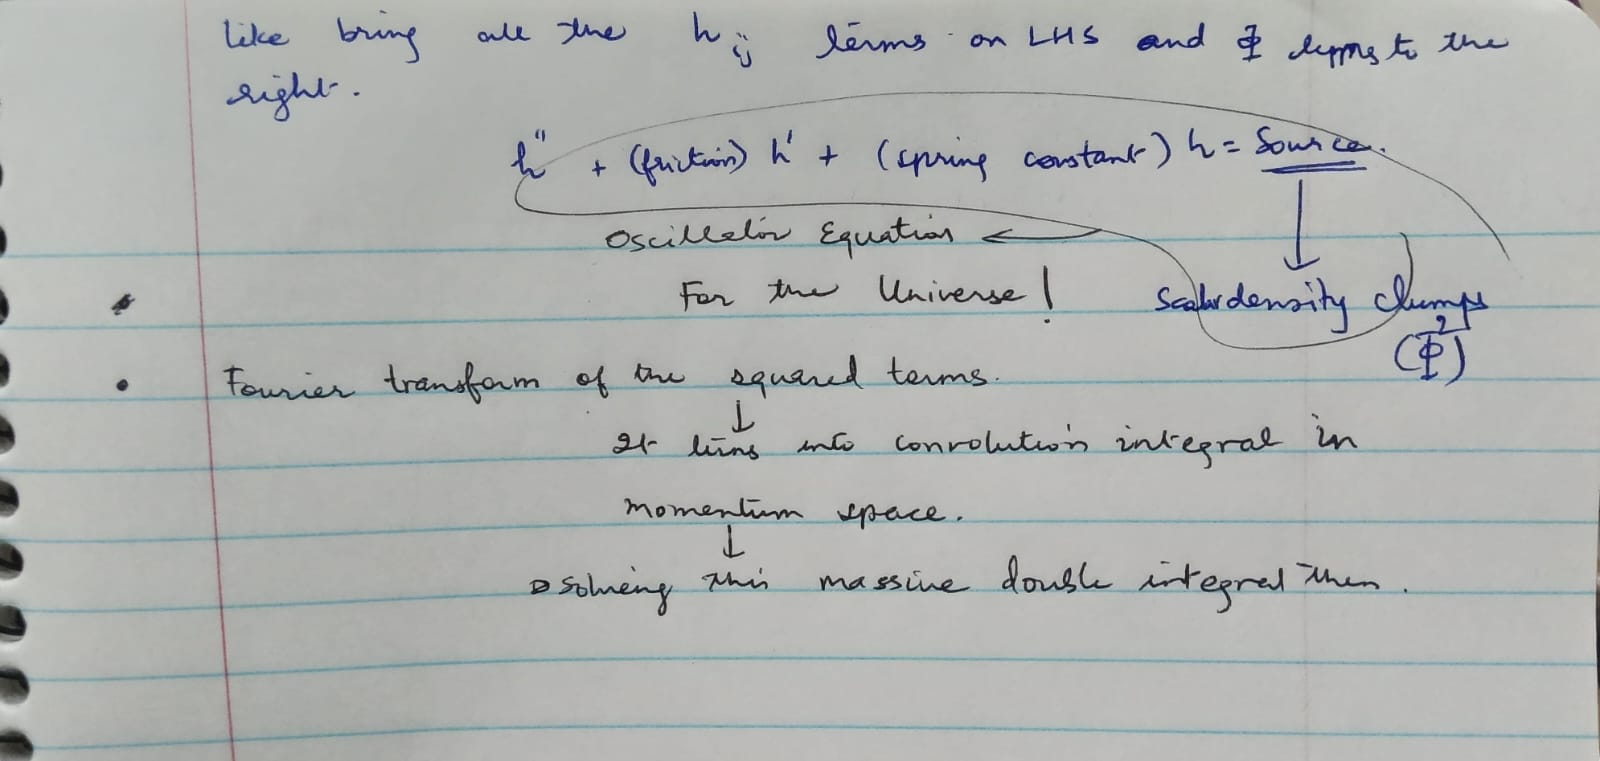

We will build a **phenomenological model** tht estimates the same thing given above in a simplified fashion.


Few assumptions and simplifications to be done for the code
*   By solving the above double integral, the gravitational energy is directly proportional to square of the power spectrum of one of the density scalar pertubations.
*   All of the dispersion into gravitational wave energy is not 100%. Most of the energy is absorbed within the plasma only a radiation factor of 10^-5 is seen. In case we had solver programs like of the form of C++/ Fortaran this efficiency can be calculated.
*   When the two scalar pertubations collide the gravitational wave is produced at slightly left to the scalar pertubations.
*   For this pipeline test we have assumed a gaussian distribution that dictates the shape of the wave. But actually the shape is not that simple.



<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1031/217373250.py:18: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('Density Spike $\mathcal{P}_\zeta(k)$', fontsize = 12, color = 'blue')


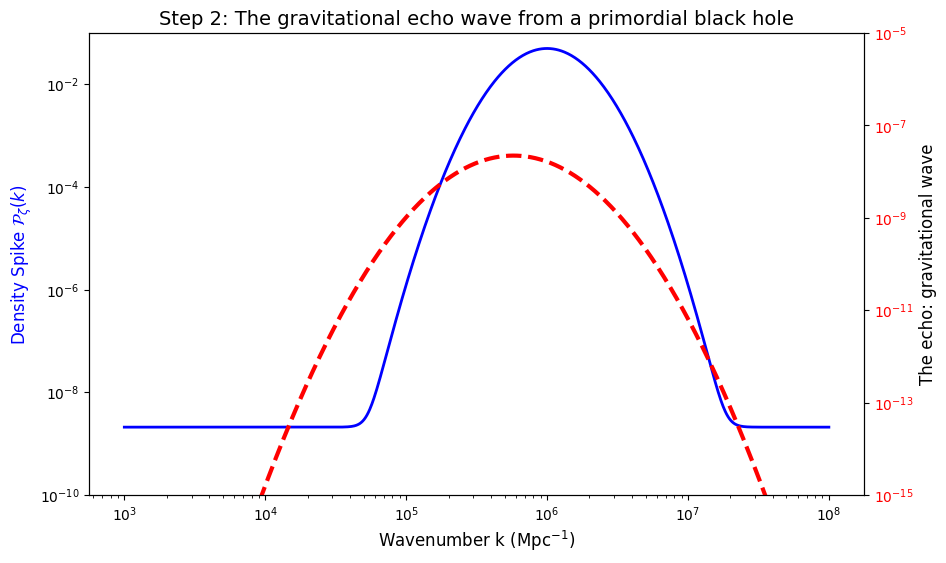

In [ ]:
def gravitational_wave_echo(k_grid, amplitude_scalar, k_star, width):
  radiation_factor = 1e-5
  peak_gw_amplitude = radiation_factor * (amplitude_scalar)**2
  # Momentum pushes the peaks upon collison slightly to the left. So the peak is pushed to k / sqrt(3)
  k_echo_peak = k_star / np.sqrt(3)

  # Draw the shape of the wave, log-normal curve is seen
  shift_factor = np.exp(-(np.log(k_grid / k_echo_peak)**2)) / (2*(width*1.5)**2)

  # Gravitational wave energy
  Omega_GW = peak_gw_amplitude * shift_factor
  return Omega_GW

Omega_GW = gravitational_wave_echo(k, amplitude, scale, width)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Wavenumber k (Mpc$^{-1}$)', fontsize = 12)
ax1.set_ylabel('Density Spike $\mathcal{P}_\zeta(k)$', fontsize = 12, color = 'blue')
ax1.plot(k, P_zeta, color = 'blue', lw = 2, label = 'Scalar Pertubation (PBH Formation)')
ax1.tick_params(axis = 'y')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim(1e-10, 1e-1)

ax2 = ax1.twinx()
ax2.set_ylabel('The echo: gravitational wave', fontsize = 12)
ax2.plot(k, Omega_GW, color='red', lw=3, linestyle='--', label="Tensor Perturbation (Gravitational Wave)")
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_yscale('log')
ax2.set_ylim(1e-15, 1e-5)

plt.title('Step 2: The gravitational echo wave from a primordial black hole', fontsize = 14)
plt.show()

## B Mode Polarizations (Telescope View)

Work in Progress